In [5]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/guilhermeonrails/data-jobs/refs/heads/main/salaries.csv")

In [3]:
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025.0,SE,FT,Solutions Engineer,214000,USD,214000,US,100,US,M
1,2025.0,SE,FT,Solutions Engineer,136000,USD,136000,US,100,US,M
2,2025.0,MI,FT,Data Engineer,158800,USD,158800,AU,0,AU,M
3,2025.0,MI,FT,Data Engineer,139200,USD,139200,AU,0,AU,M
4,2025.0,EN,FT,Data Engineer,90000,USD,90000,US,0,US,M


In [6]:
paises: dict[str, int] = {str(k): int(v) for k, v in df["employee_residence"].value_counts().to_dict().items()}

<Figure size 1000x500 with 0 Axes>

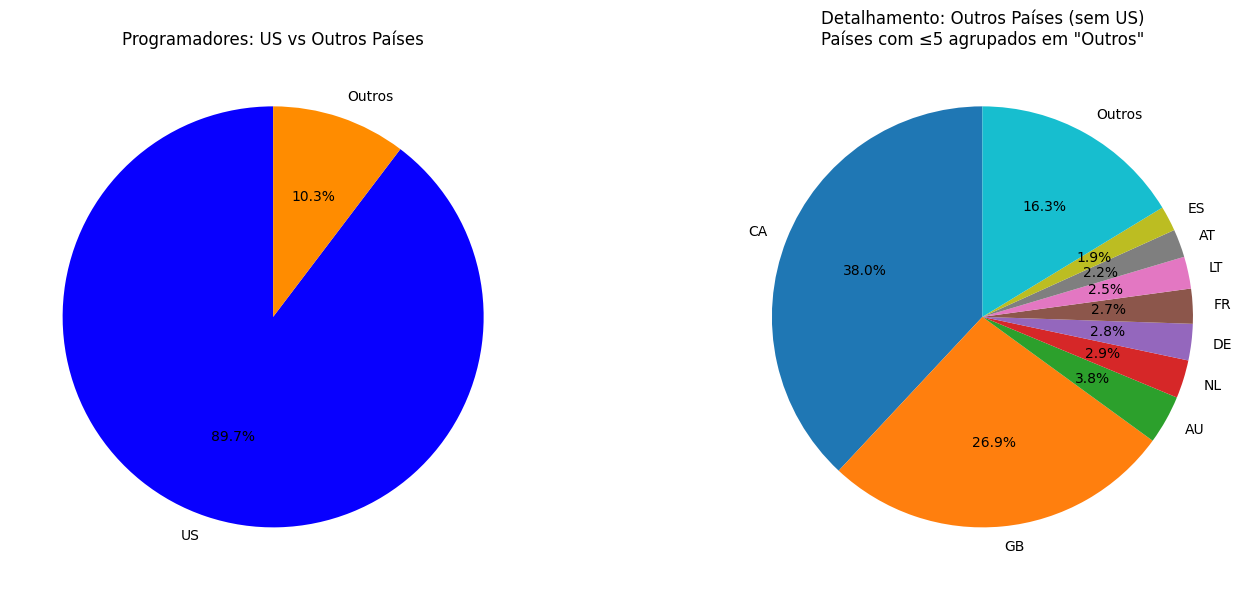

In [16]:
plt.figure(figsize=(10, 5))
us_count = paises.get('US', 0)
outros = {k: v for k, v in paises.items() if k != 'US'}
outros_total = sum(outros.values())

# Separar países com mais de 5 programadores dos menores
paises_maiores = {k: v for k, v in outros.items() if v > 250}
paises_menores_total = sum(v for v in outros.values() if v <= 250)

# Adicionar "Outros" ao dicionário se houver países pequenos
if paises_menores_total > 0:
    paises_maiores['Outros'] = paises_menores_total

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.pie(
    [us_count, outros_total],
    labels=['US', 'Outros'],
    autopct='%1.1f%%',
    startangle=90,
    colors=["#0800ff", "#ff8c00"]
)
ax1.set_title('Programadores: US vs Outros Países')

ax2.pie(
    list(paises_maiores.values()),
    labels=list(paises_maiores.keys()),
    autopct='%1.1f%%',
    startangle=90
)
ax2.set_title('Detalhamento: Outros Países (sem US)\nPaíses com ≤5 agrupados em "Outros"')

plt.tight_layout()
plt.show()

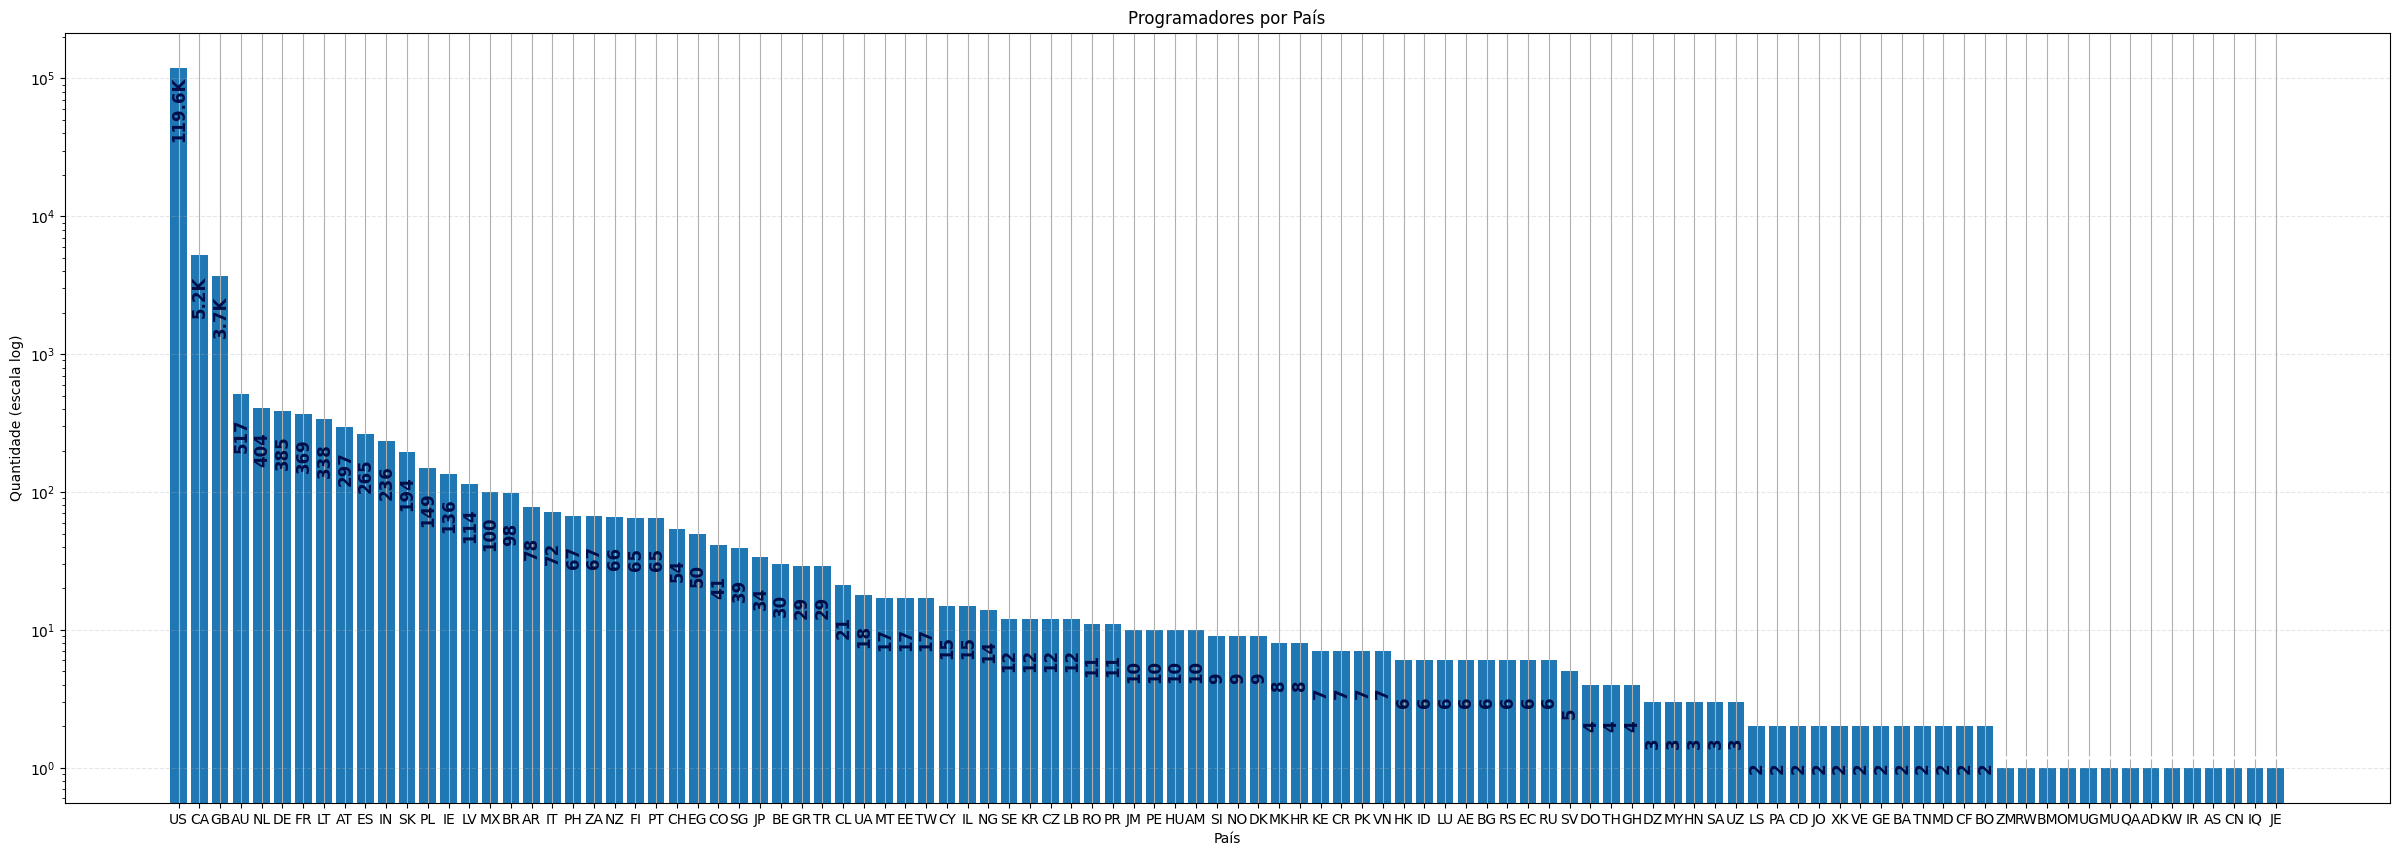

In [ ]:
plt.figure(figsize=(30, 10))

def formatar_numero(n):
    """Converte número para notação simulator"""
    if n >= 1_000_000_000:
        return f'{n/1_000_000_000:.1f}B'
    elif n >= 1_000_000:
        return f'{n/1_000_000:.1f}M'
    elif n >= 1_000:
        return f'{n/1_000:.1f}K'
    else:
        return str(int(n))

bars = plt.bar(paises.keys(), paises.values())
plt.yscale('log')

for bar in bars:
    altura = bar.get_height()
    
    if altura < 2:
        col = 'black'
        va = 'bottom'
        y_pos = altura * 1.1
    else:
        col = "white"
        va = 'center'
        y_pos = altura / 2
    
    plt.text(bar.get_x() + bar.get_width()/1.9, y_pos,
             formatar_numero(altura),
             ha='center', va=va, fontsize=12, color=col, fontweight='bold', rotation=90)

plt.xlabel('País')
plt.ylabel('Quantidade (escala log)')
plt.title('Programadores por País')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.grid(True)

plt.show()